### Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

customers = pd.read_csv("customers_features.csv")
master_df = pd.read_csv("master_dataset.csv")

### Customer Overview KPIs

In [3]:
customers

,customer_id,customer_name,email,phone,address,area,pincode,registration_date,customer_segment,total_orders,avg_order_value,CLV,customer_type
0,97475543,Niharika Nagi,ektataneja@example.org,912987579691,"23, Nayar Path, Bihar Sharif-154625",Udupi,321865,2023-05-13,Premium,13,451.92,5874.96,VIP
1,22077605,Megha Sachar,vedant45@example.com,915123179717,"51/302, Buch Chowk\nSrinagar-570271",Aligarh,149394,2024-06-18,Inactive,4,825.48,3301.92,Regular
2,47822591,Hema Bahri,samiazaan@example.com,910034076149,"941\nAnne Street, Darbhanga 186125",Begusarai,621411,2024-09-25,Regular,17,1969.81,33486.77,VIP
3,79726146,Zaitra Vig,ishanvi87@example.org,916264232390,"43/94, Ghosh, Alappuzha 635655",Kozhikode,826054,2023-10-04,New,4,220.09,880.36,Regular
4,57102800,Januja Verma,atideshpande@example.org,917293526596,"06\nOm, Ambarnath 477463",Ichalkaranji,730539,2024-03-22,Inactive,14,578.14,8093.96,VIP
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,48002829,Daksh Mandal,varkeymohammed@example.com,919587731286,"28/42, Venkataraman Ganj, Kishanganj-360157",Mumbai,45238,2024-01-25,Inactive,17,754.33,12823.61,VIP
2496,57392064,Lavanya Jain,deshpandeom@example.com,916137420258,"391, Edwin Path, Korba 202726",Udupi,688100,2024-06-23,Regular,4,1540.81,6163.24,Regular
2497,71688530,Umang Dash,gokhalenicholas@example.org,917595275963,"151, Parmer Ganj\nLoni 906431",Kavali,528749,2024-03-18,Regular,1,1541.22,1541.22,Regular
2498,89051578,Zinal Natarajan,vyasfrado@example.com,911994009448,"H.No. 172, Khanna Street, Pudukkottai 610564",Alwar,586734,2024-09-06,Premium,12,1185.50,14226.00,VIP


In [4]:
total_customers = customers['customer_id'].nunique()
average_clv = customers['CLV'].mean()
vip_customers = customers[customers['customer_type']=="VIP"].shape[0]

In [5]:
print(f"Total Customers : {total_customers}")
print(f"Average CLV : ₹{average_clv:.2f}")
print(f"VIP Customers : {vip_customers}")

Total Customers : 2500
Average CLV : ₹11610.84
VIP Customers : 1230


### Customer Segmentation

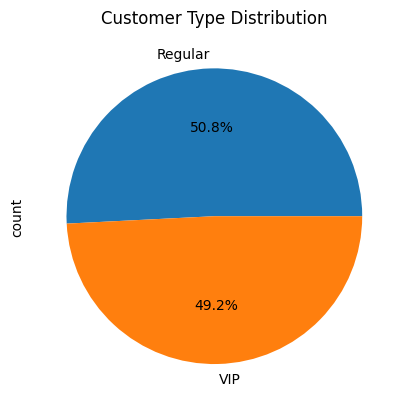

In [6]:
customers['customer_type'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title("Customer Type Distribution")
plt.show()

### Business Question
Which customer type contributes more than 10 orders,how do they called and how much customers are they?

### Observation
VIP Customers are the ones who contributes more than 10 orders and they covers the 49.2% of the total customers. 

### Recommendation
Target this customer type with personalized offers and loyalty programs.

### Customer Purchase Behavior

In [11]:
average_orders = customers['total_orders'].mean()

In [12]:
print(f"Average Orders : {average_orders:.2f}")

Average Orders : 10.49


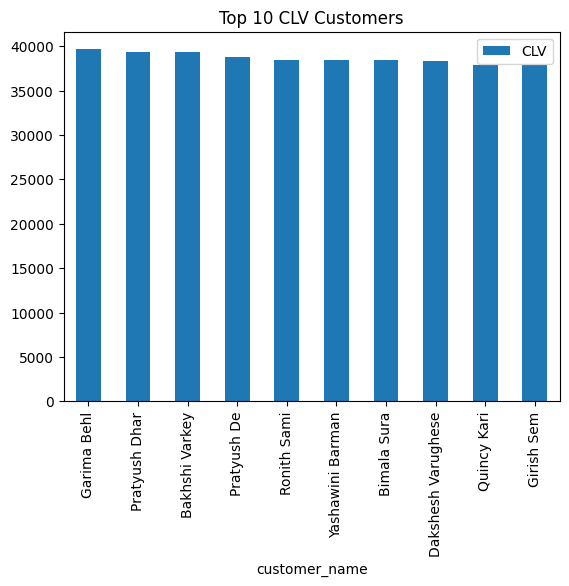

In [10]:
customers.nlargest(10,'CLV').plot(x='customer_name',y='CLV',kind='bar')
plt.title("Top 10 CLV Customers")
plt.show()

### Business Question
Which customers contributes the most in both total orders and order value perspective? May I know the top 10 customers?

### Observation
Both are clubbed together and shown as CLV and we have observed these are top 10 customers wiy highest CLV.

### Recommendation
Target this customer type with personalized offers and loyalty programs and make them retain and go with referrals.

### Customer Lifetime Value

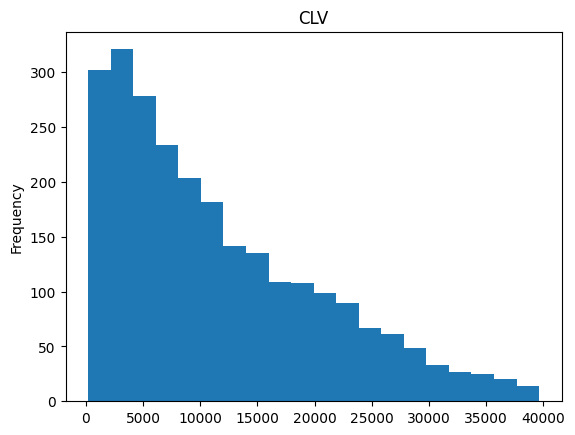

In [14]:
customers['CLV'].plot(kind='hist',bins=20)
plt.title("CLV")
plt.show()

In [18]:
highest_clv = customers['CLV'].max()
average_clv = customers['CLV'].mean()
lowest_clv = customers['CLV'].min()

In [19]:
print(f"Highest CLV : ₹{highest_clv:.2f}")
print(f"Average CLV : ₹{average_clv:.2f}")
print(f"Lowest CLV : ₹{lowest_clv:.2f}")

Highest CLV : ₹39634.40
Average CLV : ₹11610.84
Lowest CLV : ₹208.09


### Business Question
Which is the Highest CLV, Average CLV and Lowest CLV?

### Observation
Highest CLV : ₹39634.40
Average CLV : ₹11610.84
Lowest CLV : ₹208.09

### Recommendation
Highest CLV customer deserve loyalty rewards.

### Geographic Analysis

In [23]:
top_10_city = customers.groupby('area')['customer_id'].nunique().sort_values(ascending=False).head(10)
top_10_city

area
Jalna          18
Deoghar        17
Bathinda       17
Orai           17
Ratlam         16
Ghaziabad      16
Kishanganj     15
Gandhinagar    14
Nandyal        14
Kadapa         14
Name: customer_id, dtype: int64

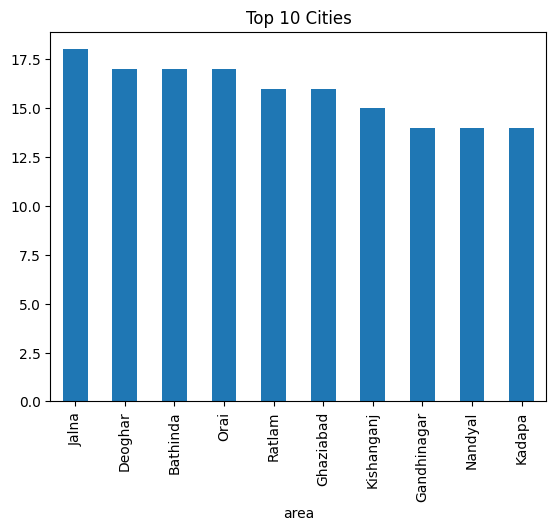

In [25]:
top_10_city.plot(kind='bar')
plt.title("Top 10 Cities")
plt.show()

### Business Question
Which city has the highest customers?

### Observation
Jalna city has the highest customers, We have also documented customer-wise top 10 cities.

### Recommendation
City based specific offers to increase customers.

In [28]:
city_sales = master_df.groupby('area')['Revenue'].sum()
city_sales.sort_values(ascending=False).head(10)

area
Orai           44503.24
Nandyal        41289.66
Gandhinagar    37950.99
Deoghar        37749.47
Ghaziabad      35394.49
Nizamabad      33225.09
Agra           32294.65
Sambalpur      32138.09
Burhanpur      31548.92
Bathinda       31476.00
Name: Revenue, dtype: float64

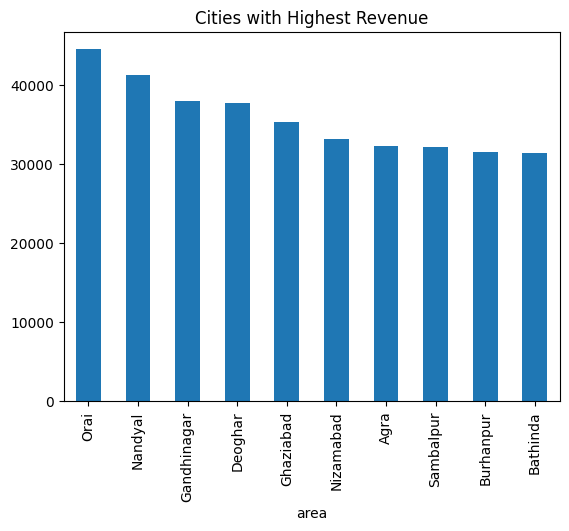

In [29]:
city_sales.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Cities with Highest Revenue")
plt.show()

### Business Question
Which city contributes most revenue?

### Observation
Orai city contributes most revenue, while we have documented top 10 cities, revenue-wise.

### Recommendation
Give revenue based offers and ask for referral.

### Loyalty Analysis

In [35]:
repeat_customers = customers[customers['total_orders']>1].shape[0]
repeat_rate = (repeat_customers/total_customers) * 100

In [36]:
print(f"Repeat Customers Rate : {repeat_rate:.2f}")

Repeat Customers Rate : 94.20


### Business Question
How many customers order more than one time?

### Observation
Nearly 94.20% Customers has ordered more than once. Above 60% → Excellent retention

### Recommendation
Focus on remaining 5.80% Customers, offer-specific and make them retain.

### Correlation Analysis

In [40]:
customers[['CLV','avg_order_value','total_orders']].corr()

,CLV,avg_order_value,total_orders
CLV,1.000000,0.616829,0.721937
avg_order_value,0.616829,1.000000,0.014875
total_orders,0.721937,0.014875,1.000000


### Business Question
Does CLV influence avg_order_value,total_orders or vice-versa?

### Observation
There is a positive correlation between CLV and avg_order_value & CLV and total_orders since we calculated CLV from these two features.

### Recommendation
There is no recommendation regarding this.